# Case Study: Student Placement Prediction
### Data Preprocessing, Visualization, and Statistical Analysis

## Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from scipy.stats import pearsonr

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("my_data (1).csv")
print(df.shape)
df.head()

(1100, 7)


,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   str    
 1   city        905 non-null    str    
 2   gender      994 non-null    str    
 3   profession  921 non-null    str    
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 60.3 KB


## (1) Handling Duplicates and Dropping Unnecessary Columns

In [4]:
print(f"Total no. of rows and columns before dropping duplicates: {df.shape}")
print("\nTotal Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Total no. of rows and columns before dropping duplicates: (1100, 7)

Total Duplicate rows: 65


,name,city,gender,profession,age,cgpa,placed
1000,castiel,asgard,male,masters,24.0,7.71,1
1001,NaN,wakanda,male,bachelor,27.0,7.90,0
1005,moriarity,asgard,male,phd,25.0,NaN,1
1006,sherlock,gotham,male,masters,28.0,7.55,1
1008,dean,wakanda,male,bachelor,20.0,9.31,0
...,...,...,...,...,...,...,...
1094,moriarity,gotham,male,NaN,26.0,7.96,0
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0


In [5]:
df = df.drop_duplicates()
print(f"Total no. of rows and columns after dropping duplicates: {df.shape}")

# checking for duplicate data
print(df.duplicated().sum())

Total no. of rows and columns after dropping duplicates: (1035, 7)
0


## (2) Detect and Handle Missing Values

In [6]:
# checking the columns for missing values
df.isnull().sum()

name           85
city          184
gender         99
profession    169
age           112
cgpa          132
placed          0
dtype: int64

We should not simply delete all these rows because that would remove a significant amount of data.

In [7]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

name           8.212560
city          17.777778
gender         9.565217
profession    16.328502
age           10.821256
cgpa          12.753623
placed         0.000000
dtype: float64


**Handling the numerical columns: age and cgpa**

In [8]:
df.dtypes

name              str
city              str
gender            str
profession        str
age           float64
cgpa          float64
placed          int64
dtype: object

In [9]:
df["age"] = df["age"].fillna(df["age"].median())
df["cgpa"] = df["cgpa"].fillna(df["cgpa"].median())

**Handling the categorical columns: name, city, gender, profession**

In [10]:
df["city"] = df["city"].fillna(df["city"].mode()[0])
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["profession"] = df["profession"].fillna(df["profession"].mode()[0])

In [11]:
df["name"] = df["name"].fillna("Unknown")

In [12]:
# Checking for missing values after filling
df.isnull().sum()

name          0
city          0
gender        0
profession    0
age           0
cgpa          0
placed        0
dtype: int64

## (3) Checking for the Correct Datatype in Each Column

In [13]:
df.dtypes

name              str
city              str
gender            str
profession        str
age           float64
cgpa          float64
placed          int64
dtype: object

In [14]:
df["age"] = df["age"].astype(int)
df.dtypes

name              str
city              str
gender            str
profession        str
age             int64
cgpa          float64
placed          int64
dtype: object

## (4) Detecting and Handling Outliers
Two common methods:
- Box Plot (Visual)
- IQR Method (Mathematical)

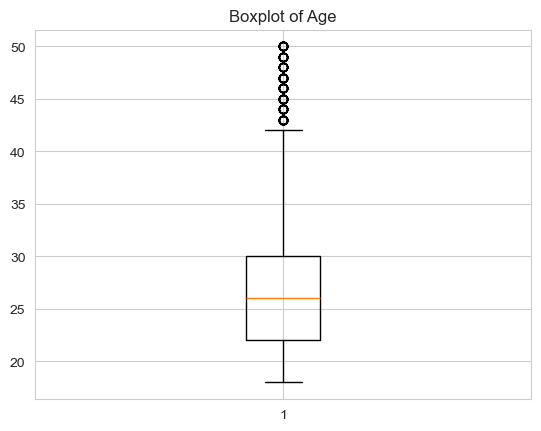

In [15]:
# Box plot for age
plt.boxplot(df["age"])
plt.title("Boxplot of Age")
plt.show()

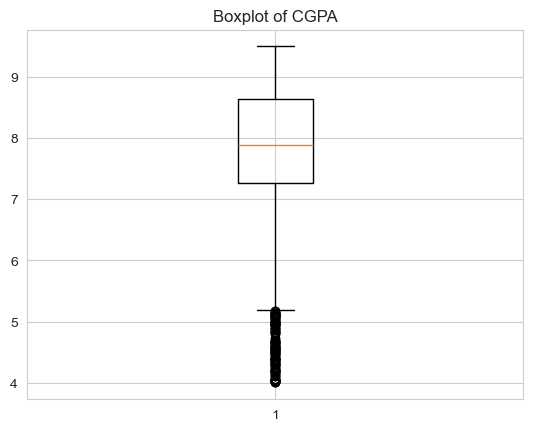

In [16]:
# Box plot for cgpa
plt.boxplot(df["cgpa"])
plt.title("Boxplot of CGPA")
plt.show()

In [17]:
# Interquartile Range
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit)
print(upper_limit)

outliers = df[(df["age"] < lower_limit) | (df["age"] > upper_limit)]
outliers

10.0
42.0


,name,city,gender,profession,age,cgpa,placed
1,moriarity,asgard,male,bachelor,50,8.55,0
12,sherlock,wakanda,male,bachelor,48,8.75,0
16,moriarity,wakanda,male,masters,43,7.74,1
27,sam,gotham,male,bachelor,44,9.30,1
32,dean,wakanda,male,masters,46,7.89,0
...,...,...,...,...,...,...,...
955,dean,gotham,female,bachelor,43,5.00,0
965,moriarity,wakanda,male,bachelor,43,8.24,0
990,sam,wakanda,male,bachelor,47,7.76,0
994,sam,gotham,male,bachelor,50,7.89,1


In [18]:
# Instead of removing rows, we replace extreme values with the boundary values.
df["age"] = df["age"].clip(lower_limit, upper_limit)

In [19]:
out_of_bounds = df[(df["age"] < lower_limit) | (df["age"] > upper_limit)]
print(f"Number of rows outside limits: {len(out_of_bounds)}")

Number of rows outside limits: 0


In [20]:
df.describe()

,age,cgpa,placed
count,1035.000000,1035.000000,1035.000000
mean,27.738164,7.606464,0.496618
std,7.570433,1.426599,0.500230
min,18.000000,4.010000,0.000000
25%,22.000000,7.260000,0.000000
50%,26.000000,7.890000,0.000000
75%,30.000000,8.640000,1.000000
max,42.000000,9.490000,1.000000


# Standardization

In [21]:
scaler = StandardScaler()

# Standardize Age
df["age_standardized"] = scaler.fit_transform(df[["age"]])

# Standardize CGPA
df["cgpa_standardized"] = scaler.fit_transform(df[["cgpa"]])

print("First 5 rows after standardization:")
print(df.head())

print("\nMean after Standardization:")
print(df[["age_standardized", "cgpa_standardized"]].mean())

print("\nStandard Deviation after Standardization:")
print(df[["age_standardized", "cgpa_standardized"]].std(ddof=0))

First 5 rows after standardization:
        name     city  gender profession  age  cgpa  placed  age_standardized  \
0  moriarity  wakanda  female        phd   28  5.94       1          0.034603   
1  moriarity   asgard    male   bachelor   42  8.55       0          1.884797   
2     holmes  wakanda  female    masters   18  5.56       0         -1.286964   
3        sam  wakanda    male   bachelor   25  8.57       1         -0.361867   
4        sam  wakanda    male   bachelor   19  8.76       1         -1.154807   

   cgpa_standardized  
0          -1.168702  
1           0.661708  
2          -1.435199  
3           0.675734  
4           0.808983  

Mean after Standardization:
age_standardized     2.540104e-16
cgpa_standardized   -1.235726e-16
dtype: float64

Standard Deviation after Standardization:
age_standardized     1.0
cgpa_standardized    1.0
dtype: float64


# Data Transformation using Binning

In [22]:
# Create Age Groups
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 60],
    labels=["Young", "Adult", "Senior"],
    include_lowest=True
)

# Create CGPA Categories (0-10 Scale)
df["CGPA_Category"] = pd.cut(
    df["cgpa"],
    bins=[4, 6, 8, 10],
    labels=["Low", "Average", "High"],
    include_lowest=True
)

print("First 5 rows after Data Transformation:\n")
print(df[["age", "Age_Group", "cgpa", "CGPA_Category"]].head())

print("\nAge Group Distribution:")
print(df["Age_Group"].value_counts())

print("\nCGPA Category Distribution:")
print(df["CGPA_Category"].value_counts())

First 5 rows after Data Transformation:

   age Age_Group  cgpa CGPA_Category
0   28     Adult  5.94           Low
1   42    Senior  8.55          High
2   18     Young  5.56           Low
3   25     Young  8.57          High
4   19     Young  8.76          High

Age Group Distribution:
Age_Group
Young     437
Adult     398
Senior    200
Name: count, dtype: int64

CGPA Category Distribution:
CGPA_Category
High       423
Average    412
Low        200
Name: count, dtype: int64


## Keep a Readable Copy Before Encoding
`city` and `profession` will be one-hot encoded and `gender` label-encoded next, which makes them hard to read in plots/tables. We keep a copy (`df_viz`) now, with the original readable labels, to use for visualization and hypothesis testing.

In [23]:
df_viz = df.copy()

# Handling with Categorical Data: Encoding Techniques

In [24]:
df.head()

,name,city,gender,profession,age,cgpa,placed,age_standardized,cgpa_standardized,Age_Group,CGPA_Category
0,moriarity,wakanda,female,phd,28,5.94,1,0.034603,-1.168702,Adult,Low
1,moriarity,asgard,male,bachelor,42,8.55,0,1.884797,0.661708,Senior,High
2,holmes,wakanda,female,masters,18,5.56,0,-1.286964,-1.435199,Young,Low
3,sam,wakanda,male,bachelor,25,8.57,1,-0.361867,0.675734,Young,High
4,sam,wakanda,male,bachelor,19,8.76,1,-1.154807,0.808983,Young,High


In [25]:
# Encoding the gender first:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df.head()

,name,city,gender,profession,age,cgpa,placed,age_standardized,cgpa_standardized,Age_Group,CGPA_Category
0,moriarity,wakanda,0,phd,28,5.94,1,0.034603,-1.168702,Adult,Low
1,moriarity,asgard,1,bachelor,42,8.55,0,1.884797,0.661708,Senior,High
2,holmes,wakanda,0,masters,18,5.56,0,-1.286964,-1.435199,Young,Low
3,sam,wakanda,1,bachelor,25,8.57,1,-0.361867,0.675734,Young,High
4,sam,wakanda,1,bachelor,19,8.76,1,-1.154807,0.808983,Young,High


In [26]:
# Encoding city and profession:
df = pd.get_dummies(
    df,
    columns=["city", "profession"],
    dtype=int
)
df.head()

,name,gender,age,cgpa,placed,age_standardized,cgpa_standardized,Age_Group,CGPA_Category,city_asgard,city_gotham,city_purgatory,city_wakanda,profession_bachelor,profession_masters,profession_phd
0,moriarity,0,28,5.94,1,0.034603,-1.168702,Adult,Low,0,0,0,1,0,0,1
1,moriarity,1,42,8.55,0,1.884797,0.661708,Senior,High,1,0,0,0,1,0,0
2,holmes,0,18,5.56,0,-1.286964,-1.435199,Young,Low,0,0,0,1,0,1,0
3,sam,1,25,8.57,1,-0.361867,0.675734,Young,High,0,0,0,1,1,0,0
4,sam,1,19,8.76,1,-1.154807,0.808983,Young,High,0,0,0,1,1,0,0


# Data Visualization

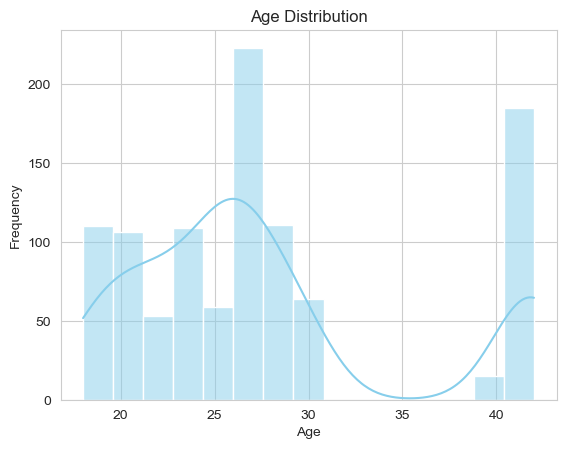

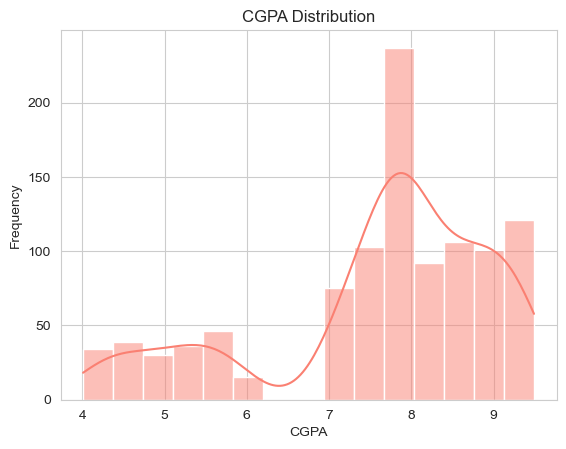

In [27]:
# Plot 1: Age Distribution
plt.figure()
sns.histplot(data=df, x="age", bins=15, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Plot 2: CGPA Distribution
plt.figure()
sns.histplot(data=df, x="cgpa", bins=15, kde=True, color="salmon")
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

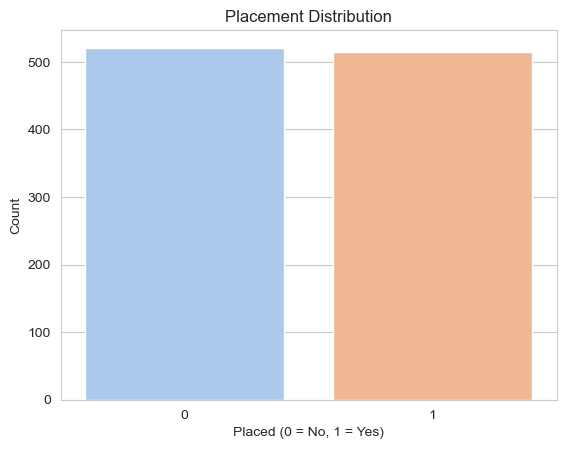

placed
0    521
1    514
Name: count, dtype: int64
placed
0    50.338164
1    49.661836
Name: proportion, dtype: float64


In [28]:
# Plot 3: Placed Distribution
plt.figure()
sns.countplot(data=df_viz, x="placed", hue="placed", palette="pastel", legend=False)
plt.title("Placement Distribution")
plt.xlabel("Placed (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print(df_viz["placed"].value_counts())
print(df_viz["placed"].value_counts(normalize=True) * 100)

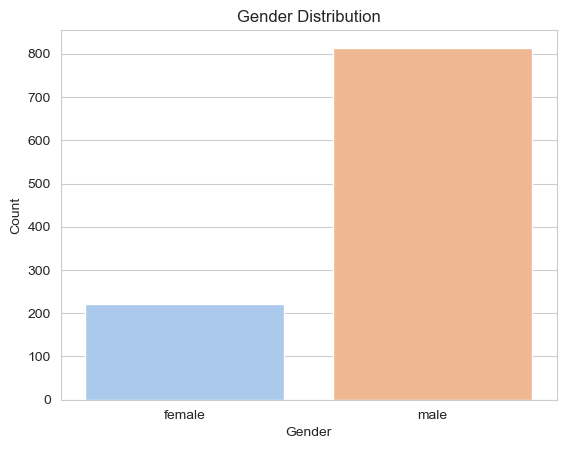

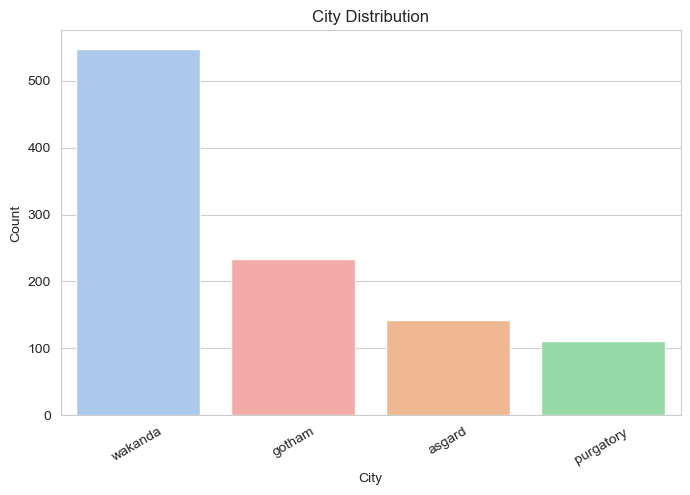

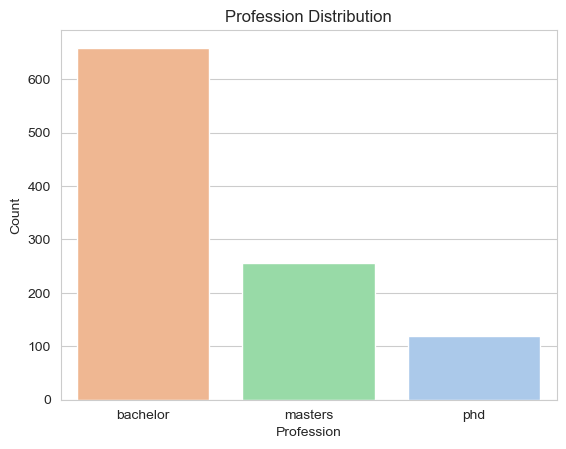

In [29]:
# Plot 4: Gender Distribution
plt.figure()
sns.countplot(data=df_viz, x="gender", hue="gender", palette="pastel", legend=False)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Plot 5: City Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_viz, x="city", hue="city", palette="pastel", legend=False,
              order=df_viz["city"].value_counts().index)
plt.title("City Distribution")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# Plot 6: Profession Distribution
plt.figure()
sns.countplot(data=df_viz, x="profession", hue="profession", palette="pastel", legend=False,
              order=df_viz["profession"].value_counts().index)
plt.title("Profession Distribution")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.show()

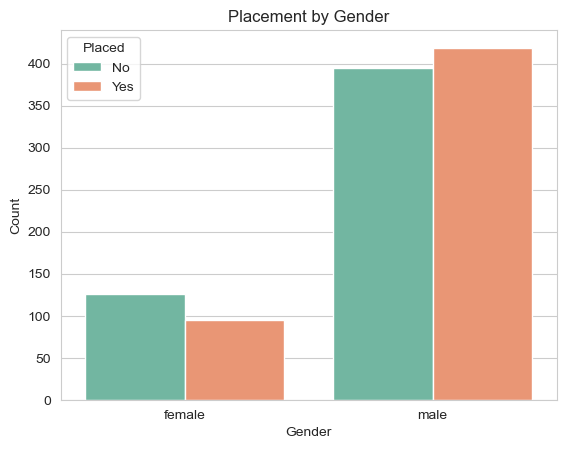

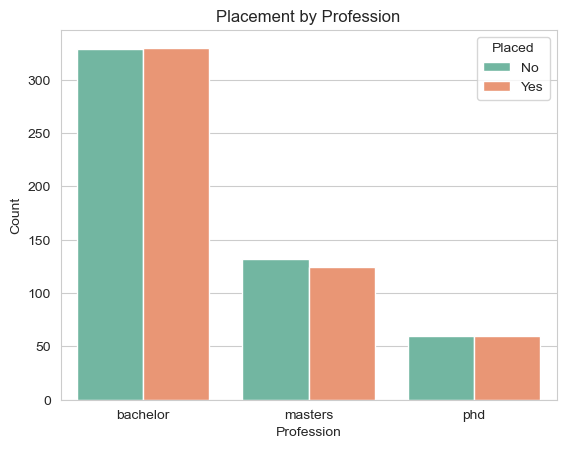

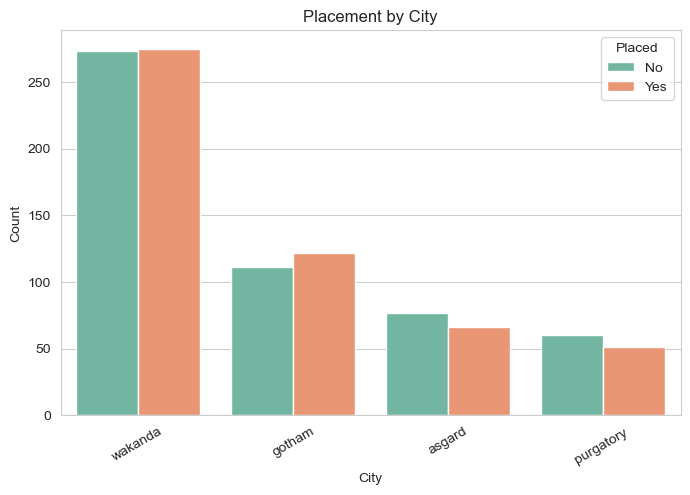

Placement rate by Gender (%):
gender
female    42.986425
male      51.474201
Name: placed, dtype: float64

Placement rate by Profession (%):
profession
bachelor    50.075873
masters     48.437500
phd         50.000000
Name: placed, dtype: float64

Placement rate by City (%):
city
asgard        46.153846
gotham        52.360515
purgatory     45.945946
wakanda       50.182482
Name: placed, dtype: float64


In [30]:
# Plot 7: Gender vs Placed
plt.figure()
sns.countplot(data=df_viz, x="gender", hue="placed", palette="Set2")
plt.title("Placement by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

# Plot 8: Profession vs Placed
plt.figure()
sns.countplot(data=df_viz, x="profession", hue="placed", palette="Set2",
              order=df_viz["profession"].value_counts().index)
plt.title("Placement by Profession")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

# Plot 9: City vs Placed
plt.figure(figsize=(8, 5))
sns.countplot(data=df_viz, x="city", hue="placed", palette="Set2",
              order=df_viz["city"].value_counts().index)
plt.title("Placement by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

print("Placement rate by Gender (%):")
print(df_viz.groupby("gender")["placed"].mean() * 100)

print("\nPlacement rate by Profession (%):")
print(df_viz.groupby("profession")["placed"].mean() * 100)

print("\nPlacement rate by City (%):")
print(df_viz.groupby("city")["placed"].mean() * 100)

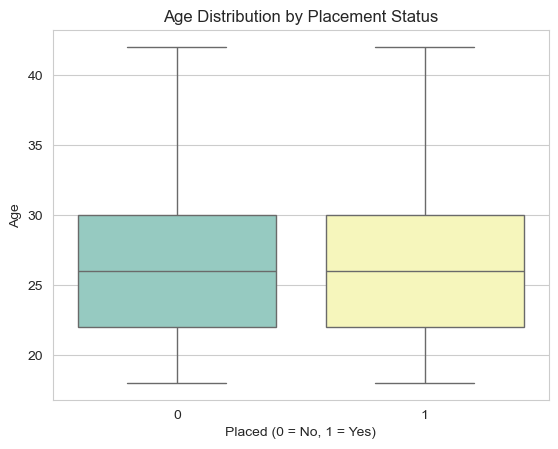

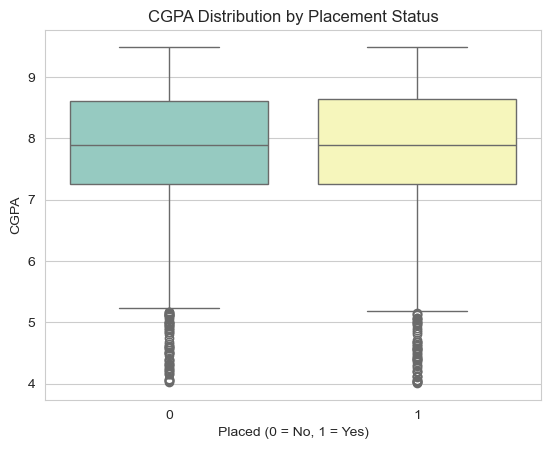

Age summary by Placement:
        count       mean       std   min   25%   50%   75%   max
placed                                                          
0       521.0  27.669866  7.404419  18.0  22.0  26.0  30.0  42.0
1       514.0  27.807393  7.741679  18.0  22.0  26.0  30.0  42.0

CGPA summary by Placement:
        count      mean       std   min   25%   50%   75%   max
placed                                                         
0       521.0  7.601190  1.406067  4.03  7.26  7.89  8.61  9.49
1       514.0  7.611809  1.448465  4.01  7.26  7.89  8.64  9.49


In [31]:
# Plot 10: Age vs Placed
plt.figure()
sns.boxplot(data=df_viz, x="placed", y="age", hue="placed", palette="Set3", legend=False)
plt.title("Age Distribution by Placement Status")
plt.xlabel("Placed (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

# Plot 11: CGPA vs Placed
plt.figure()
sns.boxplot(data=df_viz, x="placed", y="cgpa", hue="placed", palette="Set3", legend=False)
plt.title("CGPA Distribution by Placement Status")
plt.xlabel("Placed (0 = No, 1 = Yes)")
plt.ylabel("CGPA")
plt.show()

print("Age summary by Placement:")
print(df_viz.groupby("placed")["age"].describe())

print("\nCGPA summary by Placement:")
print(df_viz.groupby("placed")["cgpa"].describe())

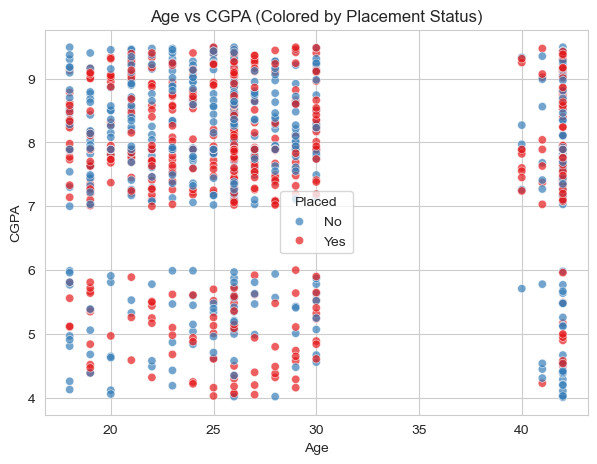

In [32]:
# Plot 12: Age vs CGPA (colored by Placement)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_viz, x="age", y="cgpa", hue="placed", palette="Set1", alpha=0.7)
plt.title("Age vs CGPA (Colored by Placement Status)")
plt.xlabel("Age")
plt.ylabel("CGPA")
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

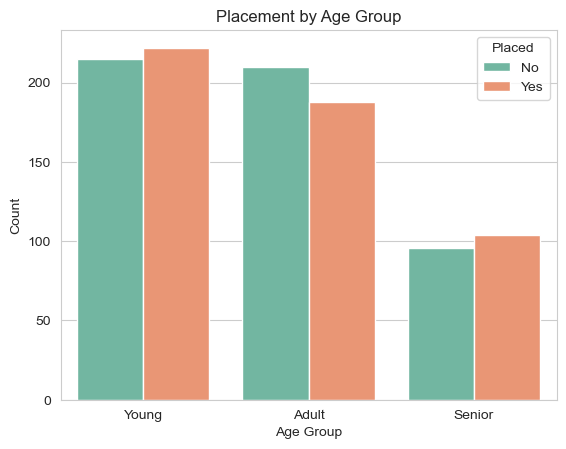

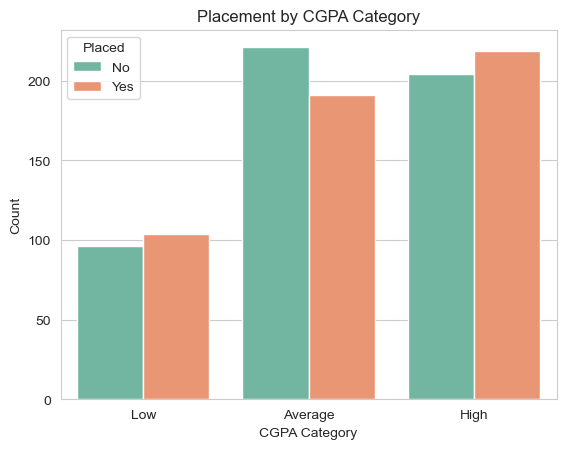

In [33]:
# Plot 13: Age_Group vs Placed
plt.figure()
sns.countplot(data=df_viz, x="Age_Group", hue="placed", palette="Set2",
              order=["Young", "Adult", "Senior"])
plt.title("Placement by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

# Plot 14: CGPA_Category vs Placed
plt.figure()
sns.countplot(data=df_viz, x="CGPA_Category", hue="placed", palette="Set2",
              order=["Low", "Average", "High"])
plt.title("Placement by CGPA Category")
plt.xlabel("CGPA Category")
plt.ylabel("Count")
plt.legend(title="Placed", labels=["No", "Yes"])
plt.show()

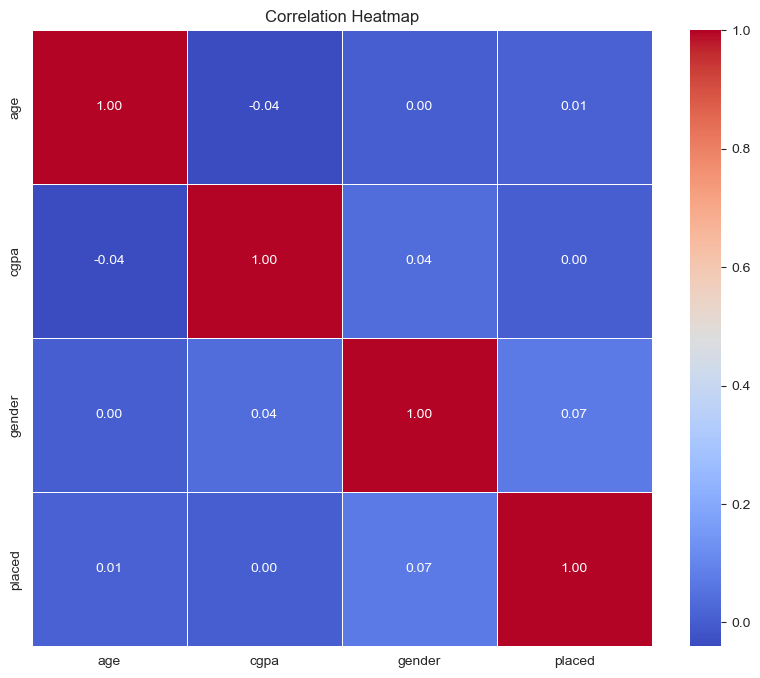

In [34]:
# Plot 15: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df[["age", "cgpa", "gender", "placed"]]  # gender already encoded here
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Statistical Analysis
### Hypothesis Testing and Correlation

## a. Hypothesis Testing

### Test 1: Independent t-test - CGPA vs Placed

**Question:** Is there a statistically significant difference in CGPA between students who got placed and those who didn't?

- **H0 (Null Hypothesis):** There is no significant difference in mean CGPA between placed and not-placed students.
- **H1 (Alternative Hypothesis):** There is a significant difference in mean CGPA between placed and not-placed students.
- **Significance level (alpha):** 0.05

In [35]:
cgpa_placed = df[df["placed"] == 1]["cgpa"]
cgpa_not_placed = df[df["placed"] == 0]["cgpa"]

t_stat, p_value = stats.ttest_ind(cgpa_placed, cgpa_not_placed)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 -> Significant difference in CGPA between placed and not-placed students.")
else:
    print("\nResult: Fail to reject H0 -> No significant difference in CGPA between placed and not-placed students.")

T-statistic: 0.1197
P-value: 0.9048

Result: Fail to reject H0 -> No significant difference in CGPA between placed and not-placed students.


### Test 2: Independent t-test - Age vs Placed

**Question:** Is there a statistically significant difference in Age between students who got placed and those who didn't?

- **H0 (Null Hypothesis):** There is no significant difference in mean Age between placed and not-placed students.
- **H1 (Alternative Hypothesis):** There is a significant difference in mean Age between placed and not-placed students.
- **Significance level (alpha):** 0.05

In [36]:
age_placed = df[df["placed"] == 1]["age"]
age_not_placed = df[df["placed"] == 0]["age"]

t_stat, p_value = stats.ttest_ind(age_placed, age_not_placed)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 -> Significant difference in Age between placed and not-placed students.")
else:
    print("\nResult: Fail to reject H0 -> No significant difference in Age between placed and not-placed students.")

T-statistic: 0.2921
P-value: 0.7703

Result: Fail to reject H0 -> No significant difference in Age between placed and not-placed students.


### Test 3: Chi-square Test - Gender vs Placed

**Question:** Is there a statistically significant association between Gender and Placement status?

- **H0 (Null Hypothesis):** Gender and Placement are independent (no association).
- **H1 (Alternative Hypothesis):** Gender and Placement are dependent (there is an association).
- **Significance level (alpha):** 0.05

In [37]:
contingency_table_gender = pd.crosstab(df_viz["gender"], df_viz["placed"])
print("Contingency Table:")
print(contingency_table_gender)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_gender)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 -> Significant association between Gender and Placement.")
else:
    print("\nResult: Fail to reject H0 -> No significant association between Gender and Placement.")

Contingency Table:
placed    0    1
gender          
female  126   95
male    395  419

Chi-square statistic: 4.6751
Degrees of freedom: 1
P-value: 0.0306

Result: Reject H0 -> Significant association between Gender and Placement.


### Test 4: Chi-square Test - Profession vs Placed

**Question:** Is there a statistically significant association between Profession (degree level) and Placement status?

- **H0 (Null Hypothesis):** Profession and Placement are independent (no association).
- **H1 (Alternative Hypothesis):** Profession and Placement are dependent (there is an association).
- **Significance level (alpha):** 0.05

In [38]:
contingency_table_prof = pd.crosstab(df_viz["profession"], df_viz["placed"])
print("Contingency Table:")
print(contingency_table_prof)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table_prof)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject H0 -> Significant association between Profession and Placement.")
else:
    print("\nResult: Fail to reject H0 -> No significant association between Profession and Placement.")

Contingency Table:
placed        0    1
profession          
bachelor    329  330
masters     132  124
phd          60   60

Chi-square statistic: 0.2042
Degrees of freedom: 2
P-value: 0.9029

Result: Fail to reject H0 -> No significant association between Profession and Placement.


## b. Correlation Analysis

We already visualized correlations using a heatmap (Plot 15). Now let's compute exact Pearson correlation coefficients along with their statistical significance (p-values).

In [39]:
pairs = [
    ("age", "cgpa"),
    ("age", "placed"),
    ("cgpa", "placed"),
]

print("Pearson Correlation Results:\n")
for col1, col2 in pairs:
    corr_coef, p_value = pearsonr(df[col1], df[col2])
    significance = "Significant" if p_value < 0.05 else "Not Significant"
    print(f"{col1} vs {col2}: r = {corr_coef:.4f}, p-value = {p_value:.4f} -> {significance}")

Pearson Correlation Results:

age vs cgpa: r = -0.0404, p-value = 0.1945 -> Not Significant
age vs placed: r = 0.0091, p-value = 0.7703 -> Not Significant
cgpa vs placed: r = 0.0037, p-value = 0.9048 -> Not Significant


In [40]:
numeric_df = df[["age", "cgpa", "gender", "placed"]]
corr_matrix = numeric_df.corr()
print("\nFull Correlation Matrix:")
print(corr_matrix.round(3))


Full Correlation Matrix:
          age   cgpa  gender  placed
age     1.000 -0.040   0.003   0.009
cgpa   -0.040  1.000   0.037   0.004
gender  0.003  0.037   1.000   0.070
placed  0.009  0.004   0.070   1.000
